In [1]:
# 기본 패키지
import numpy as np                          # 다차원 배열 및 수치 연산을 위한 NumPy 패키지 불러오기
import pandas as pd                         # 데이터프레임 형태의 구조화된 데이터 처리를 위한 pandas 패키지 불러오기
import matplotlib.pyplot as plt             # 시각화를 위한 기본 그래프 도구인 matplotlib의 pyplot 모듈 불러오기
import seaborn as sns                       # 고급 통계적 시각화를 지원하는 seaborn 패키지 불러오기

# 모델 관련
from sklearn.linear_model import LogisticRegression      # 선형 분류 모델 중 하나인 로지스틱 회귀 분류기를 불러오기
from sklearn.model_selection import train_test_split     # 데이터셋을 학습용과 테스트용으로 나누기 위한 함수 불러오기

# 모델 평가 지표
from sklearn.metrics import (                 # 모델 평가를 위한 다양한 성능 지표 함수들을 sklearn에서 불러오기 시작
    confusion_matrix,                         # 실제 값과 예측값의 오차 행렬 계산 함수
    ConfusionMatrixDisplay,                   # 혼동 행렬 시각화 클래스
    accuracy_score,                           # 정확도(정답 예측 비율) 계산 함수
    precision_score,                          # 정밀도(Positive 예측 중 정답 비율) 계산 함수
    recall_score,                             # 재현율(실제 Positive 중 예측 성공 비율) 계산 함수
    f1_score,                                 # 정밀도와 재현율의 조화 평균인 F1 점수 계산 함수
    roc_curve,                                # ROC 곡선을 그리기 위한 TPR, FPR 계산 함수
    auc,                                      # ROC 곡선의 면적(AUC) 계산 함수
    classification_report                     # 주요 평가 지표를 요약하여 텍스트 형태로 제공하는 함수
)                                             # 여러 metric을 한 번에 불러오기 위한 괄호 구조 종료

# !pip install scikit-plot                    # scikit-plot 패키지 설치 명령어 (주석 처리되어 실행되지 않음)

# imbalanced-learn 언더샘플링 도구
from imblearn.under_sampling import RandomUnderSampler   # 클래스 불균형 문제 해결을 위한 랜덤 언더샘플링 도구 불러오기

# (선택) metrics 별도 alias로 사용하고 싶을 때
import sklearn.metrics as metrics      # sklearn의 metrics 모듈을 metrics라는 별칭으로 불러오기 (가독성 향상을 위한 선택적 사용)


In [2]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
df = pd.read_csv("../../../main/datasets/heart_2020_cleaned.csv")

# 데이터 샘플 확인
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [ ]:
from sklearn.preprocessing import RobustScaler
# 이상치의 영향을 줄이기 위해 중앙값과 IQR을 기준으로 정규화를 수행하는 RobustScaler 클래스 불러오기

# 데이터 전처리

# 명목형 변수 가변수 처리 (하나의 가변수 범주 제거 옵션 적용)
df2 = pd.get_dummies(df, columns = ['HeartDisease','Smoking',
                                    'AlcoholDrinking','Stroke',
                                    'DiffWalking','Sex',
                                    'AgeCategory','Race',
                                    'Diabetic','PhysicalActivity',
                                    'GenHealth','Asthma',
                                    'KidneyDisease','SkinCancer']
                     ,drop_first=True
                    )
# 범주형(명목형) 변수들을 0 또는 1로 표현하는 더미 변수(가변수)로 변환하는 작업
# drop_first=True 옵션을 통해 다중공선성 문제를 방지하기 위해 각 변수의 첫 번째 범주를 제거하는 전략 적용
# 결과적으로 모델 학습 시 불필요한 중복 정보 제거 및 수치형 데이터 기반 분석 가능성 확보

# 숫자형 변수 분리
df_num = df[['BMI','PhysicalHealth','MentalHealth','SleepTime']]
# 원본 데이터프레임에서 연속형 수치 데이터를 별도로 추출하여 df_num에 저장하는 작업
# 추후 정규화 또는 스케일링 등 수치형 전처리 작업의 대상이 되는 컬럼 구성

df_nom = df2.drop(['BMI','PhysicalHealth','MentalHealth','SleepTime'],axis=1)
# get_dummies 처리된 데이터프레임에서 수치형 컬럼을 제거하여 명목형 더미 변수만 남기는 작업
# 숫자형과 문자형 전처리를 분리 수행한 뒤 다시 결합하기 위한 준비 단계

# 숫자형 변수 RobustScaler 적용
scaler = RobustScaler()
# 이상치에 민감하지 않은 Robust 스케일링 객체 생성

df_robust = scaler.fit_transform(df_num)
# 수치형 변수에 대해 중앙값 기준으로 표준화 스케일링을 적용하여 스케일 일관성 확보
# 평균이 아닌 중위수와 IQR(사분위 범위)를 활용하여 이상치의 영향을 최소화하는 정규화 방식 수행

# 컬럼명 결합
df_num2 = pd.DataFrame(data=df_robust, columns=df_num.columns)
# 스케일링된 numpy 배열을 원래의 컬럼명을 유지한 pandas DataFrame으로 다시 변환하는 작업
# 이후 결합을 고려한 컬럼 정합성 확보 목적

# 숫자형 테이블과 더미화 문자형 테이블 결합
df3 = pd.concat([df_num2,df_nom],axis=1)
# 전처리 완료된 수치형 테이블과 더미 변수화된 명목형 테이블을 가로방향으로 병합하여 최종 독립변수 구성
# axis=1은 열 단위 결합을 의미하며, 전체 입력 특성 행렬로 사용됨

# 독립변수와 종속변수 분리하여 생성
X = df3.drop(['HeartDisease_Yes'],axis=1)
# 심장병 여부를 나타내는 종속변수 'HeartDisease_Yes'를 제외하고 나머지를 입력변수 X로 설정하는 작업

y = df3[['HeartDisease_Yes']]
# 목표 변수인 심장병 진단 여부만 별도의 출력 변수 y로 분리 저장하는 작업
# 타겟 변수 분리 과정을 통해 학습 및 평가 단계에서 라벨과 피처를 명확히 구분함

# 학습셋과 테스트셋 분리하여 생성(7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=10)
# 전체 데이터셋을 학습용(70%)과 테스트용(30%)으로 무작위 분할하는 작업
# random_state 고정을 통해 재현 가능한 분할 결과 확보
# 분리 목적은 모델의 일반화 성능을 검증하고 오버피팅 여부를 평가하기 위함

# 학습셋과 검증셋이 잘 나뉘었는지 확인
print('train data 개수: ', len(X_train))
# 학습 데이터에 포함된 샘플 개수를 출력하여 분할이 정상적으로 이루어졌는지 확인하는 작업

print('test data 개수: ', len(X_test))
# 테스트 데이터에 포함된 샘플 개수를 출력하여 학습-테스트 분할 비율의 정확성 확인


train data 개수:  223856
test data 개수:  95939


In [ ]:
# 언더샘플링과 모델 학습 및 예측

# 임시 변수명 적용
X_train_re = X_train.copy()
# 원본 학습용 입력 데이터 X_train을 복사하여 X_train_re로 저장하는 작업
# 이후 컬럼명을 임시로 치환하여 언더샘플링 과정에 사용하기 위한 준비 단계

y_train_re = y_train.copy()
# 원본 학습용 타겟 데이터 y_train을 복사하여 y_train_re로 저장하는 작업
# 입력 특성과 함께 동일하게 임시 이름을 부여할 예정이므로 사본을 생성함

X_temp_name = ['X1','X2','X3','X4','X5','X6','X7','X8','X9','X10',
            'X11','X12','X13','X14','X15','X16','X17','X18','X19','X20',
            'X21','X22','X23','X24','X25','X26','X27','X28','X29','X30',
            'X31','X32','X33','X34','X35','X36','X37']
# 학습용 입력 데이터에 일시적으로 사용할 임의의 컬럼명 리스트 정의
# 언더샘플링 과정에서 컬럼명이 복잡할 경우 오류 방지 및 처리 단순화를 위한 사전 조치

y_temp_name = ['y1']
# 타겟 데이터에 임시로 사용할 단일 컬럼명 리스트 정의

X_train_re.columns = X_temp_name
# X_train_re의 컬럼명을 임의의 간단한 이름으로 변경하는 작업
# 언더샘플링 과정에서 컬럼명이 길거나 특수문자가 포함된 경우 발생할 수 있는 예외 방지를 위함

y_train_re.columns = y_temp_name
# y_train_re의 컬럼명을 'y1'로 임시 변경하는 작업
# 입력 컬럼과 마찬가지로 단순화를 통해 처리 오류 가능성을 제거함

# 언더샘플링 적용
X_train_under, y_train_under = RandomUnderSampler(
    random_state=0).fit_resample(X_train_re,y_train_re)
# 클래스 불균형을 해결하기 위해 다수 클래스의 데이터를 랜덤하게 제거하는 언더샘플링 적용
# RandomUnderSampler는 소수 클래스의 샘플 수에 맞게 다수 클래스 샘플을 무작위로 선택함
# 학습 시 편향을 줄이고 모델의 일반화 성능을 높이기 위한 전처리 기법

# 컬럼명 복구
X_train_under.columns = list(X_train)
# 임시로 치환되었던 컬럼명을 원래의 X_train 컬럼명으로 복원하는 작업
# 모델 해석 및 결과 분석 시 컬럼명을 직관적으로 이해하기 위해 필요한 절차

y_train_under.columns = list(y_train)
# 타겟 데이터 y_train의 원래 컬럼명으로 복원하는 작업
# 이후 예측 결과 비교 및 평가 지표 계산 시 명확한 라벨 참조를 가능하게 하기 위함

# 학습셋 모델 학습
model = LogisticRegression()
# 로지스틱 회귀 모델 객체 생성
# 이진 분류 문제 해결을 위한 선형 모델 기반 분류기로서 해석 용이성과 성능 균형이 강점인 알고리즘

model.fit(X_train_under, y_train_under)
# 언더샘플링된 학습 데이터를 이용하여 로지스틱 회귀 모델 학습 수행
# 각 특성 변수의 가중치를 학습하여 클래스 분류 경계면을 결정하는 과정

# 테스트셋에 모델 적용
y_predict = model.predict(X_test)
# 학습된 모델을 사용하여 테스트 데이터 X_test에 대한 클래스 예측 수행
# 이진 분류 결과를 0 또는 1로 출력하여 성능 평가의 입력값으로 활용됨


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 기본 혼동행렬 출력

cm = confusion_matrix(y_test, y_predict)
# 실제 정답값(y_test)과 예측값(y_predict)을 비교하여 혼동 행렬(Confusion Matrix)을 계산하는 작업
# 이진 분류 문제에서 TN, FP, FN, TP의 네 가지 값을 2×2 행렬로 반환함
# 모델의 분류 성능을 직관적으로 파악하고, 정밀도·재현율 등의 지표 계산의 기초가 되는 핵심 지표 생성

print(cm)
# 위에서 생성한 혼동 행렬을 표 형식으로 출력하는 작업
# 행은 실제 클래스, 열은 예측 클래스에 해당하며, 오분류 여부를 시각적으로 확인 가능함


[[65322 22405]
 [ 1761  6451]]


In [ ]:
# 혼동행렬 데이터 프레임 변환 
cm_df = pd.DataFrame(data=cm, 
                  index=[f"True Class-{i}" for i in range(cm.shape[0])],
                  columns=[f"Predicted Class-{i}" for i in range(cm.shape[0])])
# sklearn에서 생성한 numpy 배열 형식의 혼동 행렬(cm)을 pandas 데이터프레임 형태로 변환하는 작업
# index는 실제 클래스 라벨을 나타내며, "True Class-0", "True Class-1" 형식으로 명시함
# columns는 예측된 클래스 라벨을 나타내며, "Predicted Class-0", "Predicted Class-1" 형식으로 명시함
# 데이터프레임 형태로 구성함으로써 혼동 행렬의 시각적 가독성을 향상시키고, 후속 분석 및 시각화 작업의 편의성을 높이는 효과 확보

cm_df
# 생성된 혼동 행렬 데이터프레임을 출력하여 예측 성능의 실제 분포를 확인하는 작업
# 각 셀에 해당하는 값은 예측과 실제가 일치하거나 불일치한 샘플 수를 의미함


,Predicted Class-0,Predicted Class-1
True Class-0,65322,22405
True Class-1,1761,6451


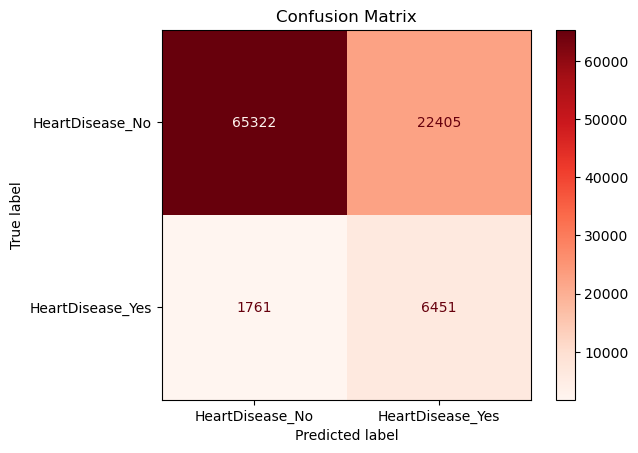

In [ ]:
import matplotlib.pyplot as plt
# 시각화를 위한 matplotlib의 기본 그래프 도구를 불러오는 작업
# 혼동 행렬 색상 매핑(cmap) 설정 및 시각화 출력을 위해 사용됨

from sklearn.metrics import ConfusionMatrixDisplay
# 혼동 행렬을 손쉽게 시각화할 수 있도록 도와주는 sklearn 내장 클래스 불러오기
# from_predictions 또는 from_estimator 방식으로 생성 가능함

# 라벨 설정
label = ['HeartDisease_No', 'HeartDisease_Yes']
# 혼동 행렬의 축(label)에 표시될 클래스 이름 정의
# 실제 클래스 0은 'HeartDisease_No', 클래스 1은 'HeartDisease_Yes'로 해석되는 의미 부여

# 혼동 행렬 시각화 (최신 방식)
ConfusionMatrixDisplay.from_estimator(model,         # 학습된 모델
                                      X_test, y_test, # 입력과 정답
                                      display_labels=label,
                                      cmap=plt.cm.Reds,
                                      normalize=None)  # 'true', 'pred', 'all' 중 하나로 정규화 가능
# 학습된 모델을 기반으로 테스트 데이터를 평가하여 혼동 행렬을 시각화하는 작업
# from_estimator 방식은 모델 객체를 직접 전달함으로써 내부적으로 predict 수행을 자동화함
# display_labels를 통해 클래스 이름을 명확하게 지정하고, cmap을 통해 붉은색 계열의 색상 매핑 지정
# normalize=None 설정은 정규화 없이 절대값으로 출력함을 의미하며, 비율 분석이 필요한 경우 'true', 'pred', 'all' 중 선택 가능함
# 전체적으로 시각적 해석과 비교를 명확하게 할 수 있는 혼동 행렬 시각화 구현

plt.title('Confusion Matrix')
# 혼동 행렬 시각화의 제목을 지정하여 그래프의 의미를 명확히 전달하는 작업

plt.grid(False)
# 불필요한 격자선(grid line)을 제거하여 시각적 노이즈를 줄이는 설정

plt.show()
# matplotlib의 시각화 결과를 실제 화면에 출력하는 명령어
# 대화형 환경 또는 스크립트 실행 환경에서 그래프가 렌더링되도록 함


In [ ]:
# 정확도, 오분류율, 정밀도, 민감도, 특이도, f-1스코어 산출

# 정확도
accuracy = model.score(X_test, y_test)
# 모델의 score 메서드를 사용하여 테스트셋에서의 분류 정확도를 계산하는 작업
# 정확도는 전체 샘플 중 정답으로 맞춘 비율을 의미하며, (TP + TN) / 전체 로 정의됨

print('정확도:{:.3f}'.format(accuracy))

# 오분류율
error_rate = 1-model.score(X_test, y_test)
# 오분류율은 전체 중에서 틀린 비율을 의미하며, 1 - 정확도로 계산함
# (FP + FN) / 전체 로 정의되며, 정확도와 상호보완적인 지표 역할을 수행함

print('오분류율:{:.3f}'.format(error_rate))

# 정밀도
precision = precision_score(y_test, y_predict)
# 예측값 중 Positive(1)로 판단한 사례 중 실제로 Positive인 비율을 계산하는 작업
# 정밀도 = TP / (TP + FP) 로 정의되며, False Positive를 줄이는 데 집중하는 평가 지표

print('정밀도:{:.3f}'.format(precision))

# 민감도(재현율)
recall = recall_score(y_test, y_predict)
# 실제 Positive(1)인 사례 중에서 모델이 Positive로 올바르게 예측한 비율을 계산하는 작업
# 민감도 = TP / (TP + FN) 으로 정의되며, 질병 예측 등 놓치면 안 되는 경우에 중요한 평가 지표

print('민감도:{:.3f}'.format(recall))

# 특이도
TN = cm_df['Predicted Class-0'].loc['True Class-0']
# 혼동 행렬에서 실제 Negative이고 예측도 Negative인 True Negative의 개수를 추출하는 작업
FP = cm_df['Predicted Class-1'].loc['True Class-0']
# 혼동 행렬에서 실제 Negative이지만 예측은 Positive인 False Positive의 개수를 추출하는 작업

print('특이도:{:.3f}'.format(TN/(TN+FP)))
# 특이도 = TN / (TN + FP) 를 계산하여 출력하는 작업
# 실제 Negative인 샘플을 얼마나 잘 Negative로 예측했는지를 평가하는 지표
# 재현율이 Positive 클래스 민감도라면, 특이도는 Negative 클래스 민감도에 해당함

# f1-스코어
f1 = f1_score(y_test, y_predict)
# 정밀도와 재현율의 조화 평균을 계산하는 작업
# f1 = 2 * (precision * recall) / (precision + recall) 로 정의됨
# 불균형 데이터 상황에서 정밀도와 재현율 간의 균형 평가를 목적으로 사용됨

print('f1-스코어:{:.3f}'.format(f1))

정확도:0.748
오분류율:0.252
정밀도:0.224
민감도:0.786
특이도:0.745
f1-스코어:0.348


In [ ]:
# 향상도 테이블 생성

# 예측 스코어 산출 및 결합
probability = model.predict_proba(X_test)
# 테스트셋에 대해 모델이 예측한 각 클래스(0, 1)의 확률값을 반환하는 작업
# 로지스틱 회귀 모델은 predict_proba 메서드를 통해 softmax 확률 또는 sigmoid 확률 값을 출력함

y_probability_df = pd.DataFrame(probability,
                                columns=['probability_0','probability_1'])
# predict_proba의 결과를 pandas 데이터프레임으로 변환하고, 각 클래스에 해당하는 확률 컬럼명을 지정하는 작업
# probability_1은 Positive 클래스(HeartDisease_Yes)에 대한 확률 값을 의미함

y_df = pd.concat([y_test.reset_index()['HeartDisease_Yes'],
                  y_probability_df['probability_1']], axis=1)
# 실제 타겟값 y_test와 모델이 예측한 확률값 중 Positive 클래스 확률(probability_1)을 병합하여 하나의 데이터프레임으로 구성하는 작업
# reset_index를 통해 인덱스를 재정렬하여 두 시리즈 간 정렬 불일치로 인한 오류 방지

# 10분위 컬럼 생성
y_df['decile'] = pd.qcut(y_df['probability_1'],10,
                         labels=['10','9','8','7','6','5','4','3','2','1'])
# 예측 확률을 기준으로 10개의 분위수(decile)로 분할하여, 높은 확률 순으로 10~1까지 라벨링하는 작업
# qcut 함수는 데이터의 분포를 기반으로 동일한 개수로 그룹을 나누며, 향상도 분석의 기본 구간으로 활용됨

# 향상도 테이블을 위한 변수 설정
y_all = y_df['HeartDisease_Yes'].sum()
# 테스트셋에서 실제 Positive 클래스(HeartDisease=Yes)의 총 개수를 계산하는 작업
# 전체 민감도(Sensitivity) 계산 시 분모로 사용됨

base_lift = y_df['HeartDisease_Yes'
                ].sum()/y_df['HeartDisease_Yes'].count()
# 전체 샘플 중 Positive 클래스 비율을 계산하여 기본 향상도(Baseline Precision)로 설정하는 작업
# 향상도(Lift) 계산에서 기준 성능으로 작용하며, 예측 성능이 우수할수록 이 값 대비 향상도가 커짐

# 분위수 별 집계
y_df_gb = y_df.groupby(['decile']).agg(
    {'HeartDisease_Yes':'sum','probability_1':'count'}).reset_index()
# 분위수별로 실제 Positive 클래스의 개수와 샘플 수를 집계하여 각 decile 구간의 빈도 통계를 계산하는 작업
# 향상도 테이블 구성의 핵심 데이터로 사용되며, reset_index를 통해 그룹핑 결과를 표 형태로 변환함

y_df_gb = y_df_gb.sort_values(by='decile' ,ascending=False)
# decile 값을 기준으로 높은 확률부터 낮은 확률 순으로 정렬하는 작업
# 향상도 분석에서는 높은 예측 확률 구간부터 얼마나 많은 Positive 클래스가 포함되어 있는지를 확인하는 것이 핵심임

# 향상도 테이블 요소 생성 및 후처리
y_df_gb['Sensitivity'] = y_df_gb['HeartDisease_Yes']/y_all
# 각 decile 구간이 전체 Positive 클래스에서 차지하는 비율(민감도)을 계산하는 작업
# 예측 상위 구간에 실제 Positive 클래스가 얼마나 집중되어 있는지를 측정함

y_df_gb['Precision'] = y_df_gb['HeartDisease_Yes']/y_df_gb['probability_1']
# 각 decile 구간에서의 정밀도를 계산하는 작업
# 해당 구간에 속한 샘플 중 실제 Positive 클래스의 비율을 의미함

y_df_gb['Lift'] = y_df_gb['Precision']/base_lift
# 해당 decile 구간의 정밀도를 전체 평균 정밀도(base_lift)로 나누어 향상도(Lift)를 계산하는 작업
# Lift는 예측 결과의 성능 향상 정도를 직관적으로 표현하는 지표로, 1보다 크면 평균 대비 우수한 성능을 의미함

y_df_gb = y_df_gb.rename(
    columns={'HeartDisease_Yes':'Frequency of Y=1','probability_1':'Decile count'})
# 분석 결과 테이블의 컬럼명을 사람이 이해하기 쉬운 표현으로 변경하는 작업
# 'Frequency of Y=1'은 해당 구간에서의 실제 Positive 클래스 수, 'Decile count'는 구간별 총 샘플 수를 의미함

y_df_gb
# 향상도 테이블 전체를 출력하여 decile 별 민감도, 정밀도, 향상도 지표를 확인하는 작업
# 이 테이블은 마케팅 응답 예측, 질병 예측, 스팸 필터링 등에서 모델 효과를 해석하는 핵심 분석 자료로 활용됨


,decile,Frequency of Y=1,Decile count,Sensitivity,Precision,Lift
9,1,3474.0,9594,0.423039,0.362101,4.230350
8,2,1819.0,9594,0.221505,0.189598,2.215028
7,3,1150.0,9594,0.140039,0.119867,1.400375
6,4,722.0,9594,0.087920,0.075255,0.879192
5,5,460.0,9593,0.056016,0.047952,0.560208
4,6,235.0,9594,0.028617,0.024494,0.286164
3,7,153.0,9594,0.018631,0.015947,0.186311
2,8,96.0,9594,0.011690,0.010006,0.116901
1,9,55.0,9594,0.006698,0.005733,0.066974
0,10,48.0,9594,0.005845,0.005003,0.058450


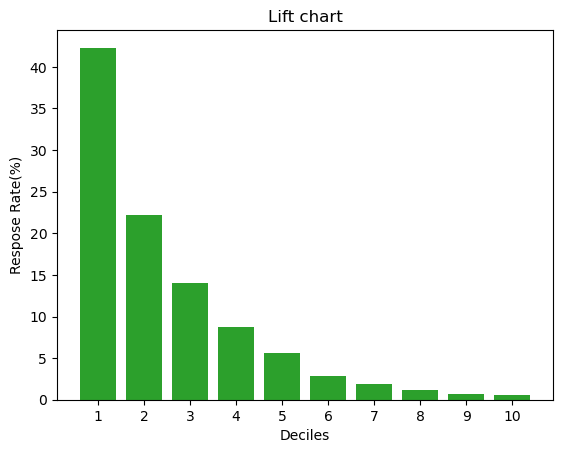

In [ ]:
# 향상도 차트 생성

bar_x = np.arange(10)
# x축에 사용할 0부터 9까지의 정수 배열 생성
# 총 10개의 분위수(decile)에 대응되는 막대그래프의 x좌표 배열로 사용됨

plt.bar(bar_x, y_df_gb['Sensitivity']*100, color='C2')
# 분위수별 민감도(Sensitivity)를 백분율로 환산하여 막대그래프 형태로 시각화하는 작업
# Sensitivity는 전체 Positive 클래스 중 해당 분위수에 포함된 비율을 나타내며, 높을수록 해당 구간의 예측력이 우수함을 의미함
# color='C2'는 matplotlib의 기본 색상 팔레트 중 초록 계열 색상을 선택하여 시각적 구분도를 확보함

plt.xticks(bar_x, y_df_gb['decile'])
# x축 눈금의 위치를 bar_x 값에 맞추고, 눈금 라벨은 해당하는 decile 값(10~1)을 표시함
# 예측 확률이 높은 구간부터 낮은 구간까지 순서를 직관적으로 전달하기 위한 설정

plt.title("Lift chart")
# 전체 그래프의 제목을 "Lift chart"로 설정하는 작업
# 향상도 그래프의 성격을 명확히 전달하고, 그래프 해석 목적을 사용자에게 안내함

plt.xlabel("Deciles")
# x축의 레이블을 'Deciles'로 지정하여, 이 차트가 확률 기반 10분위 구간을 나타냄을 명시함

plt.ylabel("Respose Rate(%)")
# y축의 레이블을 'Response Rate(%)'로 지정하여, 각 분위수 내 Positive 클래스 비율(민감도)을 백분율로 표현함을 명시함

plt.show()
# 설정한 모든 시각화 요소를 실제로 화면에 렌더링하여 출력하는 작업
# 대화형 환경 또는 스크립트 환경 모두에서 시각적 결과를 확인하기 위한 필수 호출


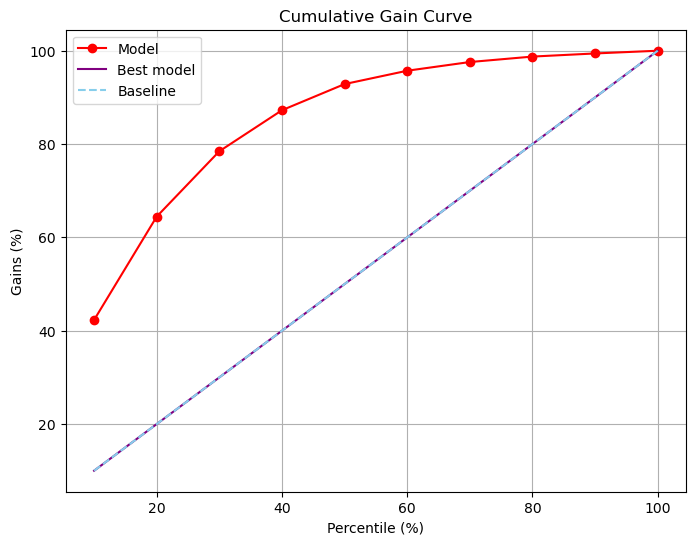

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 수치 연산과 시각화를 위한 numpy 및 matplotlib.pyplot 모듈 불러오기
# 누적 이득 곡선의 좌표 계산 및 시각화를 위한 필수 도구 패키지

# 누적 정답 수 및 전체 정답 수
y_df_gb['Cumulative Y=1'] = y_df_gb['Frequency of Y=1'].cumsum()
# 각 decile(분위수) 구간까지의 Positive 클래스(정답 1)의 누적 합계를 계산하여 새로운 컬럼으로 저장하는 작업
# 예측 확률이 높은 구간부터 얼마나 많은 양성(True Positive)을 포착했는지 누적 기준으로 표현함

total_y = y_df_gb['Frequency of Y=1'].sum()
# 전체 테스트셋에서의 Positive 클래스(정답 1)의 총 수를 계산하여 변수에 저장하는 작업
# 누적 비율 계산 및 성능 평가 기준으로 사용됨

y_df_gb['Cumulative Gain (%)'] = y_df_gb['Cumulative Y=1'] / total_y * 100
# 누적 정답 수를 전체 정답 수로 나누고 100을 곱하여 누적 이득을 백분율로 환산한 컬럼 생성
# 모델이 상위 몇 퍼센트 구간에서 전체 Positive 중 몇 퍼센트를 맞췄는지를 시각적으로 판단할 수 있도록 정규화된 형태로 표현함

# 누적 백분위 (10%, 20%, ..., 100%)
percentiles = np.arange(1, 11) * 10  # [10, 20, ..., 100]
# 분위수별 누적 비율(퍼센트 기준)을 나타내는 x축 좌표 리스트 생성
# 전체 테스트 데이터 중 상위 몇 %에 해당하는지를 구분하기 위한 기준선으로 사용됨

# Base line (랜덤 모델은 직선)
baseline = percentiles
# 무작위 예측(Random Guessing)일 경우의 기준선 정의
# 정확도와 무관하게 Positive 클래스가 데이터에 균등하게 퍼져 있다고 가정할 때 나타나는 직선

# Best model: 상위 decile에서 모든 양성을 맞췄다고 가정
# Best model이 100%에 도달하는 시점은 실제 양성 수량 기준으로 산정 가능
# (여기선 단순 비교를 위해 최대한 early gain을 가정)
best_model_gain = [min(100, 10 * (i + 1) * total_y / total_y) for i in range(10)]
# 이상적인(best) 모델의 누적 이득 곡선을 시뮬레이션하여 리스트로 생성하는 작업
# 상위 분위수부터 양성 클래스를 완벽히 식별했다고 가정하며, 이론적 최대 성능을 의미함

# 시각화
plt.figure(figsize=(8, 6))
# 그래프 크기를 가로 8, 세로 6인치로 설정하여 시각화 범위 확보

plt.plot(percentiles, y_df_gb['Cumulative Gain (%)'], label='Model', color='red', marker='o')
# 실제 모델의 누적 이득 곡선을 분위수 기준으로 선 그래프로 시각화하는 작업
# 각 점(marker)은 분위수 구간별 누적 정답률을 표시함

plt.plot(percentiles, best_model_gain, label='Best model', color='purple', linestyle='-')
# 이론적 최적 성능을 갖는 모델의 누적 이득 곡선을 시각화하여 비교 기준 제공

plt.plot(percentiles, baseline, label='Baseline', color='skyblue', linestyle='--')
# 무작위 예측 모델의 성능 기준선을 시각화하여 현재 모델의 상대적 우수성 판단 기준 제공

plt.title("Cumulative Gain Curve")
# 그래프의 제목을 지정하여 시각화 목적을 명확히 표현

plt.xlabel("Percentile (%)")
# x축 라벨을 설정하여 분위수 기준 구간임을 명시

plt.ylabel("Gains (%)")
# y축 라벨을 설정하여 누적 이득의 백분율임을 명시

plt.grid(True)
# 보조 격자선을 활성화하여 수치 해석의 가독성 향상

plt.legend()
# 범례를 출력하여 각 곡선의 의미를 명확히 구분하도록 시각적 가이드 제공

plt.show()
# 위 설정 내용을 시각적으로 출력하여 사용자에게 그래프를 렌더링하는 작업


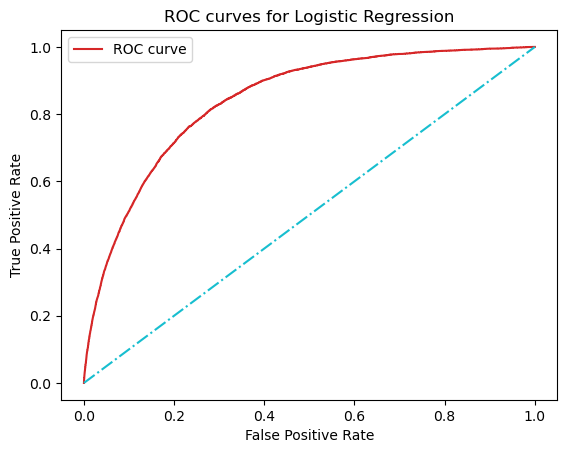

AUC 스코어:0.842


In [ ]:
# ROC 커브 생성 및 AUC 스코어 산출

# 시각화 함수 설정
def plot_roc_curve(fper, tper):
    plt.plot(fper, tper, color='C3', label='ROC curve')
    # FPR(False Positive Rate)과 TPR(True Positive Rate)을 기준으로 ROC 곡선을 그리는 작업
    # 모델의 민감도와 위양성 비율 간의 관계를 시각적으로 표현함

    plt.plot([0, 1], [0, 1], color='C9', linestyle='-.')
    # 대각선 기준선(랜덤 분류 기준)을 그려 모델 성능 비교 기준 제공
    # 이 선보다 위에 있을수록 모델의 분류 성능이 우수함을 의미함

    plt.xlabel('False Positive Rate')
    # x축 레이블을 'False Positive Rate'로 지정하여 오분류 비율의 의미를 명시함

    plt.ylabel('True Positive Rate')
    # y축 레이블을 'True Positive Rate'로 지정하여 민감도의 의미를 명시함

    plt.title('ROC curves for Logistic Regression')
    # 전체 ROC 곡선 시각화에 대한 제목 설정

    plt.legend()
    # 범례 표시를 통해 선의 의미를 명확히 구분

    plt.show()
    # 위에서 설정한 시각화 요소들을 실제 출력하여 그래프 렌더링 수행

# 예측 스코어 전처리 및 ROC 커브 생성
probability_cut = probability[:, 1]
# predict_proba로부터 Positive 클래스(1)의 예측 확률만 추출하는 작업
# ROC 커브는 확률 기반 이진 분류 모델의 성능을 평가하므로, 1 클래스에 대한 확률이 필요함

fper, tper, thresholds = roc_curve(y_test, probability_cut)
# 실제 정답(y_test)과 예측 확률을 바탕으로 FPR, TPR, threshold를 계산하는 작업
# roc_curve 함수는 다양한 임계값에 대한 FPR, TPR 쌍을 반환하여 ROC 곡선을 생성할 수 있도록 함

plot_roc_curve(fper, tper)
# 위에서 정의한 사용자 함수에 FPR, TPR 값을 넘겨 ROC 곡선을 시각화하는 작업

# AUC 스코어 산출
auc_score = auc(fper, tper)
# ROC 곡선 아래 면적인 AUC(Area Under the Curve)를 계산하여 모델의 전체 분류 성능을 수치화하는 작업
# AUC는 0.5(랜덤 수준) ~ 1.0(완벽한 분류) 사이의 값을 가지며, 모델의 판별 능력을 나타내는 핵심 지표임

print('AUC 스코어:{:.3f}'.format(auc_score))
# 계산된 AUC 값을 소수점 셋째 자리까지 출력하는 작업


In [ ]:
# 수익 곡선

# 수익, 비용 변수 정의
profit = 2000000
# 긍정 클래스(예: 질병 있음)를 올바르게 예측했을 경우 기대되는 수익을 정의함
# 예: 조기 진단으로 인해 의료비, 사회적 비용 등 절감 효과 발생 시의 가정 수익

cost = -300000
# 잘못된 예측으로 인해 발생하는 1건당 비용(예: 불필요한 검사, 오진 등)의 추정치를 음수로 정의함

# 수익, 비용 Matrix 생성
profit_cost_matrix = np.array([[profit+cost, cost],[0,0]])
# confusion matrix의 위치에 따라 수익/비용을 대응하는 행렬 정의
# TP 위치에는 올바른 예측으로 인한 수익과 비용을 합산한 값을 배치
# FP 위치에는 잘못된 예측에 따른 손실만 반영
# FN, TN은 수익에 영향을 주지 않음으로 0 처리

# 수익곡선 시각화를 위한 혼동행렬 재배열
def cm_for(y_true, y_pred):
    [[tn, fp], [fn, tp]] = metrics.confusion_matrix(y_true, y_pred)
    return np.array([[tp, fp], [fn, tn]])
# sklearn의 confusion_matrix 결과를 TP, FP, FN, TN 순서로 재배열하는 사용자 정의 함수 정의
# 수익 계산에 필요한 행렬 곱을 올바른 위치에서 수행하기 위한 구조 변환 과정

# 예측 스코어 수준 별 예상 수익 값 산출
profits = []
# 각 임계값(Threshold)에 따른 수익을 저장할 리스트 초기화

for T in sorted(y_probability_df['probability_1'], reverse=True):
    y_pred_pf = (y_probability_df['probability_1'] > np.array(T)).astype(int)
    # 현재 threshold T 이상일 경우 Positive(1)로 분류하도록 예측값 생성
    # 확률 예측 결과를 이진 클래스 결과로 변환하여 혼동 행렬 평가 가능하도록 처리함

    confusion_mat = cm_for(y_test, y_pred_pf)
    # 실제 정답과 위에서 이진화한 예측값을 기반으로 혼동 행렬을 생성하고 재배열된 형태로 반환함

    # 임계값에 대한 총 수익 계산
    profit = sum(sum(confusion_mat * profit_cost_matrix)) / len(y_test)
    # 혼동 행렬의 각 항목에 대응되는 수익/비용을 곱한 후 총합을 구하고, 전체 샘플 수로 나누어 평균 수익을 계산함
    # threshold 변경에 따라 예상 수익이 어떻게 변동되는지를 수치화하는 핵심 연산

    profits.append(profit)
    # 현재 임계값에서의 수익을 profits 리스트에 추가 저장함

# 수익곡선 시각화
profit_max = max(profits)
# 예측 임계값을 변화시킬 때 얻을 수 있는 최대 수익을 계산하여 저장함
# 최적 threshold의 간접적 판단 근거로 활용됨

plt.figure();
plt.plot(np.linspace(0, 1, len(y_test)), profits, 
         label = 'max profit per person: ₩{:.0f}'.format(profit_max))
# x축을 0~1 구간으로 균등 분할하고, 각 분할에 대해 계산된 예상 수익을 선 그래프로 시각화하는 작업
# x축은 전체 관측치에 대한 누적 비율(혹은 임계값 분포 순서)을 의미함
# y축은 개별 샘플당 기대 수익이며, 가장 수익이 높은 지점을 라벨로 표시함

plt.hlines(0,0,1,color="red")
# 기준선으로 수익=0인 수평선을 추가하여 손익분기점 시각화

plt.xlabel('Percentage of observations')
# x축 레이블을 'Percentage of observations'로 설정하여 분류 기준 임계값 분포임을 표현함

plt.ylabel('Profit')
# y축 레이블을 'Profit'으로 설정하여 평균 수익임을 명확히 표현함

plt.title('Profit Curve')
# 그래프 제목을 'Profit Curve'로 설정하여 수익 기반 평가임을 강조함

plt.legend(loc='lower left')
# 범례 위치를 좌측 하단으로 지정하여 최대 수익 구간 정보를 시각적으로 보조함

plt.show()
# 위에서 설정한 모든 시각화 내용을 실제 출력하는 작업


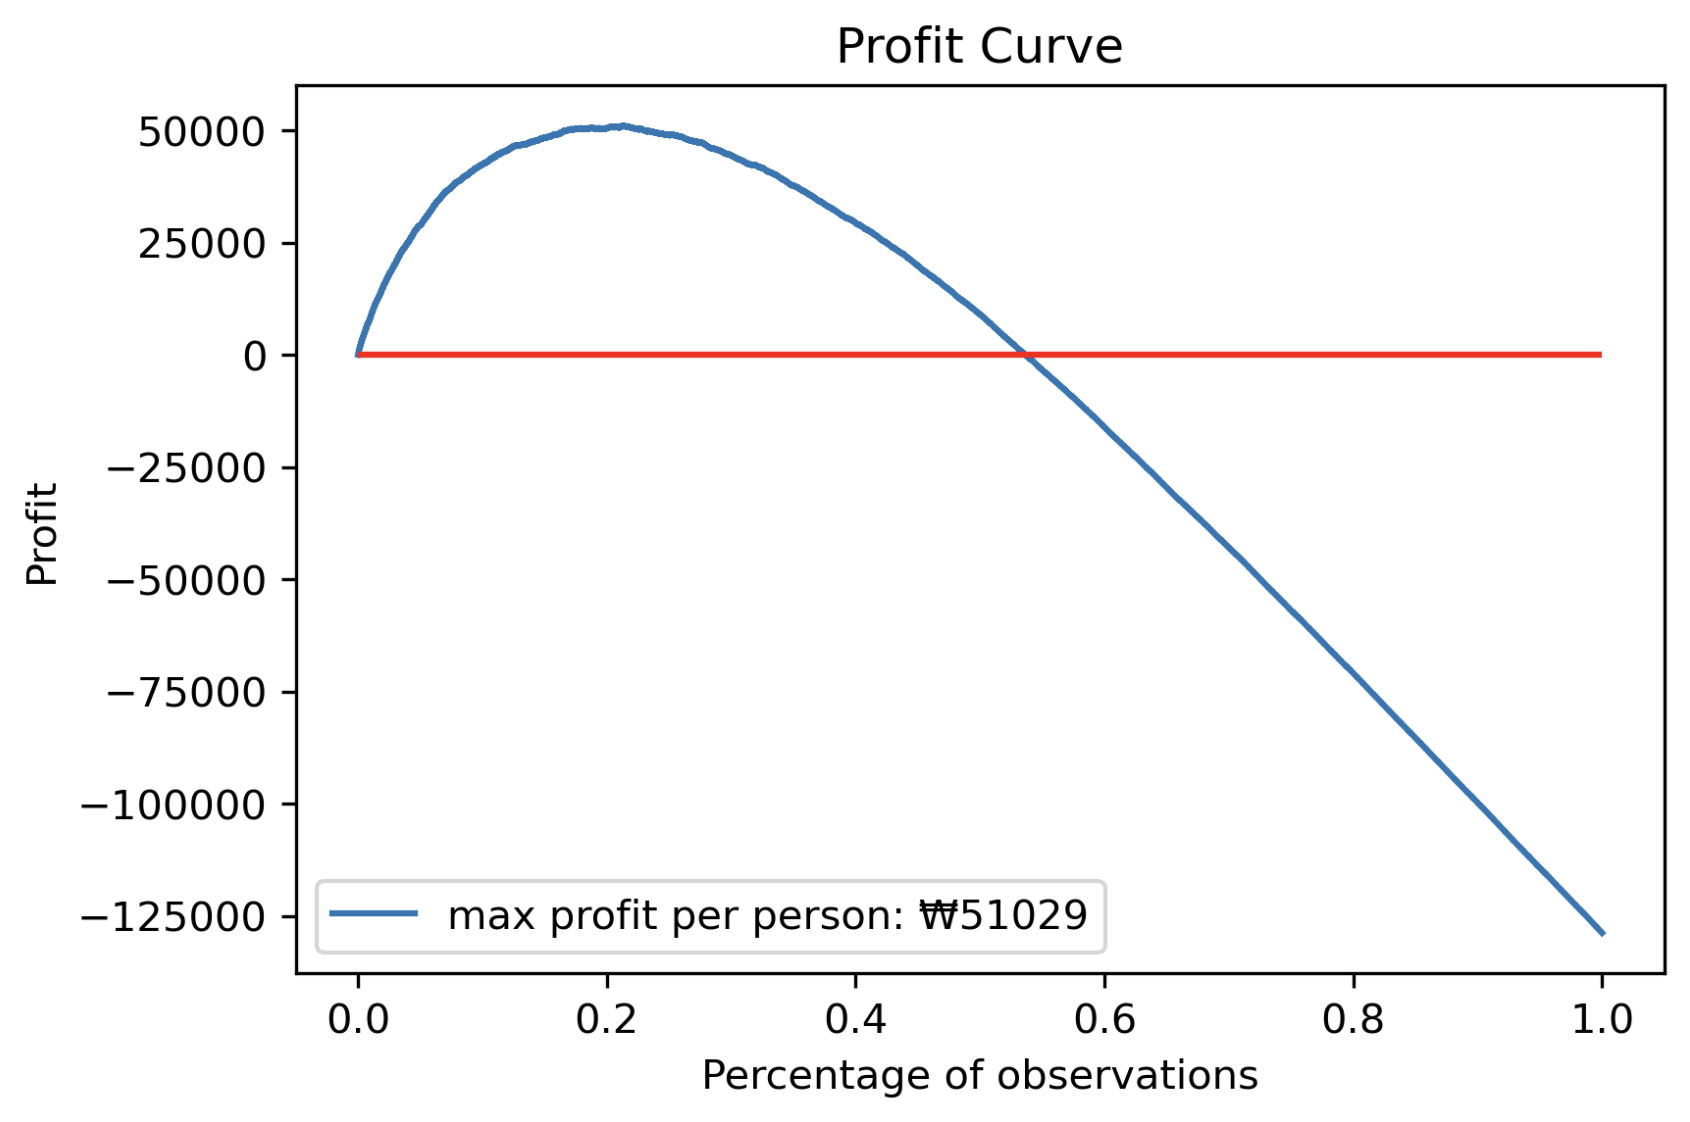

In [ ]:
# precision @ k, recall @ k, MAP 산출 (단일 고객 데이터)

# 기존 추천 결과 데이터
actual = ['A','C','D','E','H','M','P','R','S','V']
# 고객이 실제로 구매한 품목 목록을 리스트 형태로 정의한 작업
# 추천 시스템 성능 평가 시 정답 집합 역할을 수행함

predicted = ['A','D','F','H','M','N','O','P','X','Z']
# 추천 시스템이 고객에게 추천한 아이템 목록을 리스트 형태로 정의한 작업
# 추천 정확도를 평가할 예측 결과 집합 역할을 수행함

####################### K 수 지정 #######################
k = 3 # 평가지표 산출에 사용할 item 수
# Precision@K, Recall@K를 계산할 때 상위 K개의 예측 결과만 사용하도록 설정한 작업
#########################################################

r = []
# 이진 평가 결과(1: 적중, 0: 실패)를 저장할 리스트 초기화

rs = [r]
# MAP 계산을 위해 여러 사용자의 평가 결과 리스트(r)를 묶은 외부 리스트 정의
# 여기서는 단일 사용자 기반 평가이므로 r 하나만 포함함

# 예측과 실제 구매 매칭 리스트 생성
for p in predicted:
    if p in actual:
        r.append(1)
    else:
        r.append(0)
# 예측 결과(predicted)의 각 아이템이 실제 구매 품목(actual)에 포함되어 있는지를 확인하고
# 포함되면 1, 포함되지 않으면 0으로 기록하는 작업
# 이진 벡터 r은 추천이 얼마나 실제 구매와 일치했는지를 나타내는 정량적 정보로 사용됨

# precision @ k 산출 함수 설정
def precision_at_k(r, k):
    assert k >= 1
    # 입력된 k 값이 1 이상인지 확인하는 작업
    # 0 이하의 k는 평가 기준으로 부적절하므로 방어적 검증 포함

    r = np.asarray(r)[:k] != 0
    # 입력된 결과 리스트 r을 numpy 배열로 변환한 뒤 상위 k개에 대해 0이 아닌 값만 True로 마스킹함
    # 이는 상위 k개의 예측 결과 중에서 적중 여부(True/False)를 확인하기 위한 전처리 작업

    if r.size != k:
        raise ValueError('k setting error')
    # 평가 대상 개수가 k와 다를 경우 오류를 발생시켜 정확한 지표 산출을 보장함

    return np.mean(r)
    # 상위 k개 중 적중한 비율을 평균으로 반환함
    # precision@k는 추천된 k개의 아이템 중 실제로 맞춘 비율을 나타내는 지표임

# recall @ k 산출 함수 설정
def recall_at_k(r, k):
    assert k >= 1
    # k가 1 이상인지 확인하는 작업

    all_r = np.sum(r)
    # 전체 정답 개수(실제 적중해야 할 아이템 수)를 계산함

    r = np.asarray(r)[:k] != 0
    # 상위 k개 중 적중한 항목을 불리언 배열로 변환하는 작업

    if r.size != k:
        raise ValueError('k setting error')
    # k 크기와 예측 항목 수가 불일치할 경우 예외 발생

    return np.sum(r) / all_r
    # 상위 k개에서 적중한 개수를 전체 실제 정답 수로 나누어 recall 계산
    # recall@k는 전체 정답 중에서 상위 k개 안에 얼마나 포함되었는지를 나타내는 지표임

# average precision 산출 함수 설정
def average_precision(r):
    r = np.asarray(r) != 0
    # 입력된 예측 결과를 불리언 배열로 변환하여 적중 여부를 명확히 표시함

    out = [precision_at_k(r, k + 1) for k in range(r.size) if r[k]]
    # 적중한 위치에서의 precision@k를 모두 수집하여 리스트로 저장함
    # 적중 위치에서의 precision만 평가에 반영되므로, 순서와 누적 기여도를 함께 고려한 정밀도 평가 방식임

    if not out:
        return 0.
    # 만약 적중 항목이 전혀 없을 경우 average precision은 0으로 반환함

    return np.mean(out)
    # 적중 위치에서의 precision 평균을 반환함
    # average precision은 정답의 위치까지 고려한 정밀도로서, 순서에 민감한 평가 지표임

# MAP 산출 함수 설정
def mean_average_precision(rs):
    return np.mean([average_precision(r) for r in rs])
    # 여러 사용자에 대해 average precision을 각각 계산한 뒤 평균을 취하여 MAP 산출
    # MAP은 추천 시스템의 전체 품질을 요약하는 대표적인 순위 기반 평가 지표임

# print(precision_at_k(r, k))
# print(recall_at_k(r, k))
# print(mean_average_precision(rs))
# 위는 디버깅용 출력 코드로 주석 처리됨

print('precision @ k:{:.3f}'.format(precision_at_k(r, k)))
# 상위 k개의 예측 항목 중 실제로 맞춘 비율(precision@k)을 소수점 셋째 자리까지 출력함

print('recall @ k:{:.3f}'.format(recall_at_k(r, k)))
# 전체 정답 중 상위 k개 안에 포함된 비율(recall@k)을 소수점 셋째 자리까지 출력함

print('MAP:{:.3f}'.format(mean_average_precision(rs)))
# mean average precision 값을 소수점 셋째 자리까지 출력하여 모델의 전체 추천 품질을 평가함


precision @ k:0.667
recall @ k:0.400
MAP:0.835


In [ ]:
####################### K 수 지정 ####################### 
k = 3 # 평가지표 산출에 사용할 item 수
# 상위 몇 개의 추천 아이템을 평가에 사용할지를 설정하는 하이퍼파라미터 정의
# k의 값에 따라 모델 성능 평가지표가 달라지므로 비교 시 동일한 k값 유지 필요
#########################################################

# 실제 구매 품목
actual = [['A','C','D','E','H','M','P','R','S','V'],
          ['A','B','C','F','H','M','O','R','T','V'],
          ['C','D','E','F','H','M','O','R','T','V']]
# 각 고객이 실제로 구매한 아이템의 리스트를 사용자별로 정의한 작업
# 평가의 정답 레이블로 활용됨

# 예측 구매 품목
predicted = [['A','D','F','H','M','N','O','P','X','Z'],
             ['T','M','D','O','I','X','H','B','A','J'],
             ['F','D','C','I','X','B','E','P','Y','Q']]
# 각 고객에게 추천된 아이템의 리스트를 사용자별로 정의한 작업
# 추천 모델이 생성한 예측 결과로 사용됨

rs = []
# 이진 평가 결과(1: 적중, 0: 실패)를 저장할 사용자별 결과 리스트 초기화

rrs = [rs]
# MAP 계산을 위해 사용자별 평가 결과 집합(rs)을 외부 리스트로 감싸는 작업
# 구조적으로 mean_average_precision()에서 rs → rrs 처리를 위한 준비

# 구매 품목 데이터 전처리
for n, items in enumerate(predicted):
    r = []
    for item in items:
        if item in actual[n]:
            r.append(1)
        else:
            r.append(0)
    rs.append(r)
# 각 사용자에 대해 추천된 아이템이 실제 구매 목록에 포함되는지 여부를 0 또는 1로 매핑
# 결과적으로 각 사용자의 추천 정확도를 평가할 이진 리스트 생성
# 이진 리스트는 Precision, Recall, AP 계산에 직접 활용됨

# precision @ k 산출 함수 설정
def precision_at_k(rs, k):
    assert k >= 1
    # 평가 시 사용될 k 값이 1 이상인지 확인하는 작업

    rs = np.asarray(rs)[:,:k] != 0
    # rs를 numpy 배열로 변환하고, 각 사용자별로 상위 k개의 아이템 중 적중한 항목을 불리언으로 표시함

    if rs.shape[1] != k:
        raise ValueError('k setting error')
    # 배열의 두 번째 축(열)이 k와 다르면 에러 발생
    # 추천 결과 길이가 k보다 작을 경우 오류 방지를 위한 방어 로직 포함

    return np.mean([np.mean(arr) for arr in rs])
    # 각 사용자별 precision@k를 계산하고, 전체 사용자 평균을 반환함
    # 사용자 수준의 정밀도를 집계하여 시스템 전반의 추천 품질을 측정함

# recall @ k 산출 함수 설정
def recall_at_k(rs, k):
    assert k >= 1
    # k 유효성 검사 수행

    rs = np.asarray(rs) != 0
    # 전체 추천 결과를 불리언 배열로 변환하여 적중 여부만 고려

    tmp = []
    for arr in rs:
        all_r = np.sum(arr)
        # 해당 사용자에 대해 실제 적중해야 할 아이템 수 계산 (정답 개수)

        arr = arr[:k] != 0
        # 상위 k개 중에서 적중한 항목 추출

        if arr.size != k:
            raise ValueError('k setting error')

        tmp.append(np.sum(arr) / all_r)
        # 해당 사용자의 recall@k를 계산하여 리스트에 저장

    return np.mean(tmp)
    # 전체 사용자에 대한 recall@k 평균을 반환함

# average precision 산출 함수 설정
def average_precision(rs):
    rs = np.asarray(rs) != 0
    # 전체 사용자 추천 결과를 불리언 배열로 변환

    precision_li = []
    for arr in rs:
        tmp = []
        for k in range(arr.size):
            if arr[k]:
                tmp.append(np.mean(arr[:k+1] != 0))
        precision_li.append(np.mean(tmp))
    # 각 사용자에 대해 적중 위치에서의 precision을 모두 계산하여 평균을 구함
    # average precision은 정답이 얼마나 앞쪽에 위치했는지에 대한 순서 민감 정밀도 지표임

    if not precision_li:
        return 0
    # 정답이 하나도 없는 경우 예외 방지를 위해 0 반환

    return np.mean(precision_li)
    # 전체 사용자에 대한 average precision 평균을 반환

# MAP 산출 함수 설정
def mean_average_precision(rrs):
    return np.mean([average_precision(r) for r in rrs])
    # 여러 사용자에 대한 average precision을 평균하여 MAP 값을 계산함
    # 추천 결과의 전반적인 랭킹 품질을 측정하는 핵심 지표임

print('precision @ k:{:.3f}'.format(precision_at_k(rs, k)))
# 상위 k개의 예측 항목 중 적중 비율 평균을 소수점 셋째 자리까지 출력함

print('recall @ k:{:.3f}'.format(recall_at_k(rs, k)))
# 전체 정답 중 상위 k개 안에 포함된 비율 평균을 소수점 셋째 자리까지 출력함

print('MAP:{:.3f}'.format(mean_average_precision(rrs)))
# mean average precision 값을 소수점 셋째 자리까지 출력하여 추천 시스템의 순위 기반 정확도를 평가함


precision @ k:0.778
recall @ k:0.494
MAP:0.832
